# Nakuru Road Condition Assessment
**Author:** Gerald Omollo Otana

## Overview

This notebook detects and maps road surface hazards — **potholes and cracks
from a fine-tuned RDD2022 model, plus a carried-through poor-drainage class**
— for a pilot area in Nakuru City, using:

- **RDD2022** (your downloaded zip files) to fine-tune a YOLO model from scratch
- **Mapillary** street-level crowdsourced imagery as the raw visual source
- **OSMnx** for the underlying road network and segment referencing
- **Google Earth Engine (GEE)** for study-area context layers
- **GeoPandas** for all spatial joins, aggregation, and export
- **Leaflet + MapillaryJS** for a click-to-view live street-imagery viewer

The final stages adapt the cloud-side *validation → severity classification →
alert generation* logic used in vehicle-sensor IoT road-hazard systems
(Hemavathy & Rajakumari, 2026, *IRJAEM* 4(3):286–289) to this imagery-first
pipeline: instead of correlating reports from multiple vehicles, we correlate
detections across multiple Mapillary images at the same road segment.

Each road segment is then rolled up into a single overall condition label —
**Good / Moderate / Poor** — driven by the worst hazard detected on it. §8
gives a Folium overview map (click a road for its photo + summary); §9 adds a
second, live viewer where **clicking anywhere on the map** loads the actual
nearest Mapillary photo into an embedded, pannable MapillaryJS viewer.

> **On "real-time":** Mapillary's crowdsourced coverage is continuously
> updated, so this notebook always pulls the *most recently available*
> imagery at run time — that's different from a live video feed. If you
> re-run §4 periodically, the condition map refreshes with whatever new
> street-level coverage has appeared for Nakuru since the last run.

> **RDD2022 has no drainage class.** It only labels crack and pothole
> variants, so the fine-tuned model in §5 will only ever emit `pothole` and
> `crack` — `poor_drainage` stays wired through the severity/condition logic
> for whenever you add a labeled drainage source, but this model alone won't
> produce it. See 5b for the exact class mapping.

>


## 0. Setup

Install and import dependencies. Run this cell first in Colab.

In [ ]:
# Colab / fresh-environment setup
!pip install -q earthengine-api geemap osmnx geopandas shapely folium mapillary ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4

In [ ]:
import os
import json
import glob
import shutil
import random
import zipfile
import datetime as dt
import xml.etree.ElementTree as ET
from typing import Dict, Optional, List

import ee
import geemap
import osmnx as ox
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
from PIL import Image
from shapely.geometry import Point, box
from ultralytics import YOLO
from IPython.display import HTML, IFrame, display

ox.settings.log_console = False
print("Environment ready.")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Environment ready.


### 0b. Load the hazard validation & alert module

Writes out `hazard_validation_alerts.py` — the same module available as a
standalone file — so severity classification, multi-image consensus, alert
generation, and the Good/Moderate/Poor condition rollup all live in one
place. Sections 7, 7b, and 9 below call into this module instead of
redefining the logic inline, so the notebook and the standalone script can
never drift apart.

In [ ]:
%%writefile hazard_validation_alerts.py
"""
Hazard Validation, Severity Classification, Alert Generation &
Road Condition Rollup
Nakuru Road Condition Assessment - GEOSK 2026

Adapted from the cloud-side validation / severity classification / alert
generation logic in:
  Hemavathy, N. & Rajakumari, R. (2026). "IoT Based Real Time Road Hazard
  Detection and Alert System Using Smart Streetlight and Smart Road Studs."
  IRJAEM, 4(3), 286-289.

Their pipeline validates accelerometer events across multiple vehicles,
classifies severity, and pushes RF alerts to smart road studs. This module
substitutes:
  accelerometer events       -> YOLO/RDD2022 detections on Mapillary images
  multi-vehicle correlation  -> multi-image / multi-pass consensus per
                                 OSMnx road segment
  RF alert to road studs     -> GeoJSON alert layer (dashboard now;
                                 roadside dissemination as future work)

On top of the per-hazard alert layer, this module also rolls detections up
into a single Good / Moderate / Poor condition label per road segment (the
worst hazard on a segment governs its condition), attaching a representative
street-level photo to every segment - this mirrors §6b/§7b of the
companion notebook, `Nakuru_Road_Condition_Assessment.ipynb`, so the two
stay in sync.

Drop this file next to your notebook and
`from hazard_validation_alerts import *`, or paste the cells directly.
"""

import geopandas as gpd
import pandas as pd
from typing import Dict, Optional
from shapely.geometry import Point

# 1. Severity classification (per hazard)


# Base severity weight per hazard class - tune against ground truth
# RDD2022 label taxonomy (pothole, crack, poor_drainage).
HAZARD_BASE_WEIGHT = {
    "pothole": 0.6,
    "crack": 0.3,
    "poor_drainage": 0.5,
}

# Road class multiplier (OSMnx 'highway' tag). Hazards on higher-order
# roads get escalated faster - mirrors the paper's use of spatial context
# when validating a hazard.
ROAD_CLASS_MULTIPLIER = {
    "trunk": 1.4,
    "primary": 1.3,
    "secondary": 1.15,
    "tertiary": 1.0,
    "residential": 0.85,
    "unclassified": 0.8,
}

# Road condition rollup thresholds and colors - keep identical to §7b in
# the notebook so both artifacts always classify the same way.
CONDITION_THRESHOLDS = {
    "Good": 0.35,      # composite severity below this -> Good
    "Moderate": 0.65,  # composite severity below this -> Moderate, else Poor
}
CONDITION_COLOR = {
    "Good": "#2A9D8F",
    "Moderate": "#F4A300",
    "Poor": "#E63946",
}


def bbox_area_score(bbox_area_px: float, image_area_px: float) -> float:
    """Proxy for physical hazard size: fraction of frame occupied by the
    detection box, normalized to 0-1 (capped at 25% of the frame)."""
    frac = min(bbox_area_px / image_area_px, 0.25) / 0.25
    return round(frac, 3)


def classify_severity(
    hazard_type: str,
    confidence: float,
    bbox_area_px: float,
    image_area_px: float,
    road_class: str = "tertiary",
    n_corroborating_images: int = 1,
) -> Dict:
    """
    Combine detection confidence, apparent size, road importance, and
    multi-image corroboration (this pilot's substitute for the paper's
    multi-vehicle validation) into a single severity score and label.
    """
    base = HAZARD_BASE_WEIGHT.get(hazard_type, 0.4)
    size = bbox_area_score(bbox_area_px, image_area_px)
    road_mult = ROAD_CLASS_MULTIPLIER.get(road_class, 1.0)
    corroboration = min((n_corroborating_images - 1) * 0.08, 0.2)

    score = (0.5 * base + 0.3 * size + 0.2 * confidence) * road_mult + corroboration
    score = round(min(score, 1.0), 3)

    if score >= 0.75:
        label = "critical"
    elif score >= 0.55:
        label = "high"
    elif score >= 0.35:
        label = "medium"
    else:
        label = "low"

    return {"severity_score": score, "severity_label": label}


def condition_from_score(score: float) -> str:
    """Maps a composite severity score to the Good / Moderate / Poor
    road-condition label used for the segment-level rollup."""
    if score < CONDITION_THRESHOLDS["Good"]:
        return "Good"
    elif score < CONDITION_THRESHOLDS["Moderate"]:
        return "Moderate"
    return "Poor"



# 2. Multi-image consensus (the paper's "hazard validation" step)


def aggregate_detections_by_segment(
    detections: pd.DataFrame,
    segment_id_col: str = "osm_segment_id",
    hazard_type_col: str = "hazard_type",
) -> pd.DataFrame:
    """
    Groups YOLO detections that fall on the same OSMnx road segment so
    repeated Mapillary passes of the same physical defect count as
    corroboration rather than separate hazards - mirroring the paper's
    step of grouping events reported by multiple vehicles within a
    defined spatial window.

    Expected columns in `detections`: image_id, hazard_type, confidence,
    bbox_area_px, lat, lon, capture_date, osm_segment_id.
    """
    grouped = (
        detections
        .dropna(subset=[segment_id_col])
        .groupby([segment_id_col, hazard_type_col])
        .agg(
            n_corroborating_images=("image_id", "nunique"),
            mean_confidence=("confidence", "mean"),
            max_bbox_area_px=("bbox_area_px", "max"),
            mean_lat=("lat", "mean"),
            mean_lon=("lon", "mean"),
            first_seen=("capture_date", "min"),
            last_seen=("capture_date", "max"),
        )
        .reset_index()
    )
    return grouped


def aggregate_images_by_segment(
    images_df: pd.DataFrame,
    segment_id_col: str = "osm_segment_id",
) -> pd.DataFrame:
    """
    Picks the most recent Mapillary image per road segment as the
    representative "street view" photo - computed over the FULL set of
    retrieved images, not just ones with a hazard detection, so segments
    in good condition still have a supporting photo to show on click.

    Expected columns in `images_df`: image_id, thumb_url, capture_date,
    osm_segment_id (already snapped to the road network).
    """
    return (
        images_df
        .dropna(subset=[segment_id_col])
        .sort_values("capture_date")
        .groupby(segment_id_col)
        .tail(1)[[segment_id_col, "thumb_url", "capture_date"]]
        .rename(columns={
            "thumb_url": "representative_thumb_url",
            "capture_date": "representative_capture_date",
        })
    )


# ---------------------------------------------------------------------------
# 3. Alert generation -> GeoJSON (the paper's "alert message" step)
# ---------------------------------------------------------------------------

def generate_alerts(
    aggregated: pd.DataFrame,
    image_area_px: float,
    road_class_lookup: Optional[Dict[str, str]] = None,
) -> gpd.GeoDataFrame:
    """
    Produces a GeoDataFrame of per-hazard alerts (type, severity, location,
    corroboration count) ready to drive a color-coded point layer - the
    imagery-pipeline equivalent of the paper's cloud-generated alert
    message (hazard type, severity, precise location) that in a full
    deployment could be pushed to roadside infrastructure.
    """
    road_class_lookup = road_class_lookup or {}
    records = []
    for _, row in aggregated.iterrows():
        road_class = road_class_lookup.get(row["osm_segment_id"], "tertiary")
        sev = classify_severity(
            hazard_type=row["hazard_type"],
            confidence=row["mean_confidence"],
            bbox_area_px=row["max_bbox_area_px"],
            image_area_px=image_area_px,
            road_class=road_class,
            n_corroborating_images=row["n_corroborating_images"],
        )
        records.append({
            "osm_segment_id": row["osm_segment_id"],
            "hazard_type": row["hazard_type"],
            "severity_score": sev["severity_score"],
            "severity_label": sev["severity_label"],
            "n_corroborating_images": row["n_corroborating_images"],
            "first_seen": row["first_seen"],
            "last_seen": row["last_seen"],
            "geometry": Point(row["mean_lon"], row["mean_lat"]),
        })

    gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:4326")
    gdf["alert_color"] = gdf["severity_label"].map({
        "critical": "#8B00FF",  # purple - echoes the paper's compound-event code
        "high": "#E63946",      # red
        "medium": "#F4A300",    # amber
        "low": "#2A9D8F",       # teal - informational only
    })
    return gdf


# 4. Segment-level condition rollup: Good / Moderate / Poor


def classify_segment_condition(
    alerts: gpd.GeoDataFrame,
    edges: gpd.GeoDataFrame,
    representative_images: Optional[pd.DataFrame] = None,
    segment_id_col: str = "osm_segment_id",
    length_epsg: int = 21037,
) -> gpd.GeoDataFrame:
    """
    Rolls per-hazard alerts up into ONE overall condition label per road
    segment. The worst hazard present on a segment governs its condition
    (the "worst governs" convention used in pavement condition indices).
    Segments with no detections default to "Good". If provided,
    `representative_images` (see `aggregate_images_by_segment`) is merged
    in so every segment carries a representative photo for a click popup.

    `edges` must contain: osm_segment_id, highway_class, name, geometry
    (LineString, WGS84).
    """
    if len(alerts):
        worst = (
            alerts.sort_values("severity_score", ascending=False)
            .drop_duplicates(segment_id_col)
            [[segment_id_col, "hazard_type", "severity_score"]]
            .rename(columns={
                "hazard_type": "dominant_hazard_type",
                "severity_score": "condition_score",
            })
        )
        seg_stats = (
            alerts.groupby(segment_id_col)
            .agg(
                hazard_types_present=("hazard_type", lambda s: ", ".join(sorted(set(s)))),
                total_corroborating_images=("n_corroborating_images", "sum"),
                last_surveyed=("last_seen", "max"),
            )
            .reset_index()
        )
        seg_condition = worst.merge(seg_stats, on=segment_id_col)
    else:
        seg_condition = pd.DataFrame(columns=[
            segment_id_col, "dominant_hazard_type", "condition_score",
            "hazard_types_present", "total_corroborating_images", "last_surveyed",
        ])

    edges_condition = edges.merge(seg_condition, on=segment_id_col, how="left")
    edges_condition["condition_score"] = edges_condition["condition_score"].fillna(0.0)
    edges_condition["dominant_hazard_type"] = edges_condition["dominant_hazard_type"].fillna("none detected")
    edges_condition["hazard_types_present"] = edges_condition["hazard_types_present"].fillna("none detected")
    edges_condition["total_corroborating_images"] = (
        edges_condition["total_corroborating_images"].fillna(0).astype(int)
    )
    edges_condition["condition_label"] = edges_condition["condition_score"].apply(condition_from_score)
    edges_condition["condition_color"] = edges_condition["condition_label"].map(CONDITION_COLOR)
    edges_condition["length_m"] = edges_condition.geometry.to_crs(epsg=length_epsg).length.round(1)

    if representative_images is not None:
        edges_condition = edges_condition.merge(representative_images, on=segment_id_col, how="left")

    if "name" in edges_condition.columns:
        edges_condition["road_name"] = edges_condition["name"].apply(
            lambda n: n[0] if isinstance(n, list) else (n if pd.notna(n) else "Unnamed road")
        )

    return edges_condition


def condition_summary_table(edges_condition: gpd.GeoDataFrame) -> pd.DataFrame:
    """Segment count and total length per condition label - the same
    table exported in §9 of the notebook."""
    return (
        edges_condition.groupby("condition_label")
        .agg(segment_count=("osm_segment_id", "count"), total_length_m=("length_m", "sum"))
        .reset_index()
        .sort_values("condition_label")
    )

# Example notebook usage

if __name__ == "__main__":
    # `detections`: output of your RDD2022/YOLO inference step, one row per
    # detected hazard per Mapillary image, already spatially joined to
    # OSMnx segment IDs (e.g. via nearest-edge snapping in OSMnx/GeoPandas).
    detections = pd.read_csv("nakuru_yolo_detections.csv")
    # `images_df`: ALL retrieved Mapillary images (not just ones with a
    # detection), also snapped to `osm_segment_id`, used for representative
    # photos on segments with no detected hazards.
    images_df = pd.read_csv("nakuru_mapillary_images.csv", parse_dates=["capture_date"])
    # `edges`: the OSMnx road network GeoDataFrame from the notebook's §3.
    edges = gpd.read_file("nakuru_edges.geojson")

    agg = aggregate_detections_by_segment(detections)
    alerts = generate_alerts(agg, image_area_px=1920 * 1080)
    alerts.to_file("nakuru_road_alerts.geojson", driver="GeoJSON")

    representative_images = aggregate_images_by_segment(images_df)
    edges_condition = classify_segment_condition(alerts, edges, representative_images)
    edges_condition.to_file("nakuru_road_condition.geojson", driver="GeoJSON")

    print(alerts["severity_label"].value_counts())
    print(condition_summary_table(edges_condition))


Writing hazard_validation_alerts.py


In [ ]:
from hazard_validation_alerts import (
    classify_severity,
    aggregate_detections_by_segment,
    aggregate_images_by_segment,
    generate_alerts,
    classify_segment_condition,
    condition_summary_table,
    CONDITION_THRESHOLDS,
    CONDITION_COLOR,
)
print("Hazard validation & alert module loaded.")


Hazard validation & alert module loaded.


## 1. Earth Engine authentication

In [ ]:
# TODO: replace with your GEE Cloud project ID
GEE_PROJECT = "versatile-lotus-461214-t0"

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print("Earth Engine initialized.")


Earth Engine initialized.


## 2. Study area — Nakuru City pilot boundary

Pull the Nakuru City boundary as both an `ee.Geometry` (for any GEE context
layers you add later, e.g. land cover or nighttime lights) and a GeoDataFrame
(for the road-network and imagery steps).

AOI bounds: [     36.016    -0.35975      36.163    -0.25911]


<Axes: >

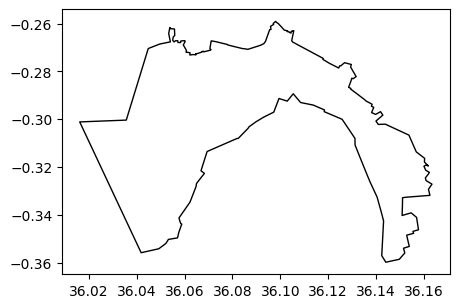

In [ ]:
place_name = "Nakuru, Kenya"

# Vector boundary via OSMnx (also used to bound the Mapillary image query)
aoi_gdf = ox.geocode_to_gdf(place_name)
aoi_geom_gpd = aoi_gdf.geometry.iloc[0]
minx, miny, maxx, maxy = aoi_gdf.total_bounds

# Mirror as an ee.Geometry for any GEE-side layers
aoi_ee = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

print(f"AOI bounds: {aoi_gdf.total_bounds}")
aoi_gdf.plot(edgecolor="black", facecolor="none", figsize=(5, 5))


## 3. Road network (OSMnx)

Pull the drivable road network for the pilot area and keep the edges as a
GeoDataFrame with a stable `osm_segment_id` and the `highway` class — this
is what hazard detections get snapped to later, and what drives the
road-class severity multiplier.

12761 road segments loaded for Nakuru, Kenya.


<Axes: >

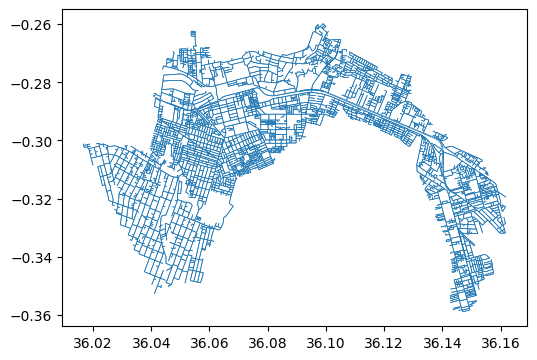

In [ ]:
G = ox.graph_from_polygon(aoi_geom_gpd, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

edges["osm_segment_id"] = (
    edges["u"].astype(str) + "_" + edges["v"].astype(str) + "_" + edges["key"].astype(str)
)

# highway can be a list when a way has multiple tags — keep the first value
edges["highway_class"] = edges["highway"].apply(
    lambda h: h[0] if isinstance(h, list) else h
)

road_class_lookup = dict(zip(edges["osm_segment_id"], edges["highway_class"]))
print(f"{len(edges)} road segments loaded for {place_name}.")
edges.plot(figsize=(6, 6), linewidth=0.5)


## 4. Mapillary imagery retrieval

Query the Mapillary Graph API for images captured within the AOI, tiled into
small bboxes and merged (see §4a — the API rejects large bboxes since a
January 2026 policy change). Adjust `MAX_IMAGES` and the capture-date filter
to control run time and recency.

> **Which credential do you actually need?** Just the **Client Token** —
> nothing else. Go to
> [mapillary.com/dashboard/developers](https://mapillary.com/dashboard/developers),
> open your registered app, and copy the **Client Token** field (it looks
> like `MLY|1234567890|abcdef...`). That single token is what goes in
> `MAPILLARY_ACCESS_TOKEN` below **and** in `MAPILLARY_CLIENT_TOKEN` in §9 —
> for read-only calls like these, Mapillary doesn't distinguish a
> "server" token from a "browser" one; there's just the one Client Token.
>
> **What `client_id`, `client_secret`, and the `/connect` URL are for:**
> those belong to the full OAuth 2.0 *user* login flow (needed only if your
> app uploads imagery on behalf of a logged-in user). `/connect` is step one
> of that flow — visiting it returns a temporary authorization *code*, not a
> token, and it must then be exchanged server-side using your client secret.
> None of that is needed here. If you plug `client_id` or `client_secret`
> straight into `access_token=`, the API will reject it — that's almost
> certainly the internal server error you hit.

In [ ]:

MAPILLARY_ACCESS_TOKEN = "MLY|27893933266957432|4869ca62322e00c448bcdc4f1b434e72"
MAX_IMAGES = 500

import requests

# 4a. Quick token sanity check
# Cheap 1-image request so a bad token fails fast with a clear message,
# instead of failing deep inside the full tiled pull below.
_check = requests.get(
    "https://graph.mapillary.com/images",
    params={"access_token": MAPILLARY_ACCESS_TOKEN, "fields": "id", "limit": 1},
)
if _check.status_code == 200:
    print("Token OK - Mapillary API reachable.")
else:
    print(f"Token check failed: HTTP {_check.status_code}")
    print(_check.text[:500])
    print("Invalid Token")


Token OK - Mapillary API reachable.


In [ ]:
def fetch_mapillary_images(bbox, token, limit=500, min_capture_date=None):
    '''Query the Mapillary Graph API for image metadata within a bbox.

    bbox: (minx, miny, maxx, maxy) in WGS84
    Returns a DataFrame with image_id, lat, lon, compass_angle, capture_date,
    thumb_url, width, height.
    '''
    url = "https://graph.mapillary.com/images"
    params = {
        "access_token": token,
        "bbox": ",".join(map(str, bbox)),
        "fields": "id,geometry,compass_angle,captured_at,thumb_2048_url,width,height",
        "limit": min(limit, 500),
    }
    records, fetched = [], 0
    while url and fetched < limit:
        resp = requests.get(url, params=params if fetched == 0 else None)
        resp.raise_for_status()
        data = resp.json()
        for feat in data.get("data", []):
            lon, lat = feat["geometry"]["coordinates"]
            captured = dt.datetime.fromtimestamp(feat["captured_at"] / 1000)
            if min_capture_date and captured < min_capture_date:
                continue
            records.append({
                "image_id": feat["id"],
                "lat": lat,
                "lon": lon,
                "compass_angle": feat.get("compass_angle"),
                "capture_date": captured,
                "thumb_url": feat.get("thumb_2048_url"),
                "width": feat.get("width"),
                "height": feat.get("height"),
            })
            fetched += 1
        url = data.get("paging", {}).get("next")
    return pd.DataFrame(records)


### 4b. Tile the AOI and pull images

As of January 2026, Mapillary rejects `bbox` queries larger than 0.01
square degrees — roughly a few city blocks, nowhere near a whole city like
Nakuru. This cell splits the AOI into a grid of small tiles, queries each
one, and merges + deduplicates the results.

In [ ]:
TILE_SIZE_DEG = 0.008  # ~0.000064 sq deg per tile - comfortably under the 0.01 limit

def make_bbox_tiles(minx, miny, maxx, maxy, tile_size=TILE_SIZE_DEG):
    tiles = []
    x = minx
    while x < maxx:
        x2 = min(x + tile_size, maxx)
        y = miny
        while y < maxy:
            y2 = min(y + tile_size, maxy)
            tiles.append((x, y, x2, y2))
            y = y2
        x = x2
    return tiles

tiles = make_bbox_tiles(minx, miny, maxx, maxy)
print(f"AOI split into {len(tiles)} tiles (each <= {TILE_SIZE_DEG}x{TILE_SIZE_DEG} deg).")

frames = []
total = 0
for tminx, tminy, tmaxx, tmaxy in tiles:
    if total >= MAX_IMAGES:
        break
    tile_df = fetch_mapillary_images(
        bbox=(tminx, tminy, tmaxx, tmaxy),
        token=MAPILLARY_ACCESS_TOKEN,
        limit=min(500, MAX_IMAGES - total),
        min_capture_date=dt.datetime(2024, 1, 1),
    )
    if len(tile_df):
        frames.append(tile_df)
        total += len(tile_df)

images_df = (
    pd.concat(frames, ignore_index=True).drop_duplicates(subset="image_id")
    if frames else pd.DataFrame(columns=[
        "image_id", "lat", "lon", "compass_angle", "capture_date",
        "thumb_url", "width", "height",
    ])
)
print(f"{len(images_df)} Mapillary images retrieved for the pilot area.")
images_df.head()


AOI split into 247 tiles (each <= 0.008x0.008 deg).
0 Mapillary images retrieved for the pilot area.


,image_id,lat,lon,compass_angle,capture_date,thumb_url,width,height


In [ ]:
def download_image(url, out_path):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)

os.makedirs("mapillary_images", exist_ok=True)
for _, row in images_df.iterrows():
    out_path = f"mapillary_images/{row['image_id']}.jpg"
    if not os.path.exists(out_path) and row["thumb_url"]:
        download_image(row["thumb_url"], out_path)
print("Image download complete.")


Image download complete.


## 5. Hazard detection model — fine-tune YOLO on RDD2022

This section turns your downloaded RDD2022 zip file(s) into a trained
detector: extract → convert Pascal VOC annotations to YOLO format → fine-tune
→ evaluate → run on the Nakuru Mapillary imagery from §4. Each step is its
own cell so you can re-run just the parts you need (e.g. skip straight to
§5e once you already have trained weights).

### 5a. Extract & inventory the RDD2022 dataset

RDD2022 ships one folder per country (Czech, India, Japan, Norway,
United_States, China_MotorBike, China_Drone), each with `train/images` +
`train/annotations/xmls` (Pascal VOC) and a `test/images` folder with no
labels (held out for the original challenge, so it's not usable for
fine-tuning here — we only touch `train/`).

In [ ]:
import kagglehub
path = kagglehub.dataset_download("alaagaberh/rdd2022")

Using Colab cache for faster access to the 'rdd2022' dataset.


In [ ]:
import os
import glob
import shutil


# Set RDD2022_EXTRACT_DIR directly to this path.

print(f"Kagglehub extracted to (raw path): {path}")
print(f"Contents of raw path: {os.listdir(path)}")

# The RDD2022 dataset from Kagglehub often has an extra top-level folder inside the extracted 'path'.
#Check for 'RDD2022_Dataset_Master' or similar.
subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
if "RDD2022_Dataset_Master" in subdirs:
    RDD2022_EXTRACT_DIR = os.path.join(path, "RDD2022_Dataset_Master")
    print(f"Found 'RDD2022_Dataset_Master' subdirectory. Adjusted RDD2022_EXTRACT_DIR to: {RDD2022_EXTRACT_DIR}")
elif len(subdirs) == 1: # If there's only one subdir, assume it's the actual dataset root
    RDD2022_EXTRACT_DIR = os.path.join(path, subdirs[0])
    print(f"Found single subdirectory '{subdirs[0]}'. Adjusted RDD2022_EXTRACT_DIR to: {RDD2022_EXTRACT_DIR}")
else:
    RDD2022_EXTRACT_DIR = path
    print(f"No specific subdirectory pattern found. Using raw path as RDD2022_EXTRACT_DIR: {RDD2022_EXTRACT_DIR}")

print(f"Final RDD2022_EXTRACT_DIR set to: {RDD2022_EXTRACT_DIR}")
print(f"Contents of final RDD2022_EXTRACT_DIR: {os.listdir(RDD2022_EXTRACT_DIR)}")

# The detection and processing of annotation files will now happen in the next cell (5b).

Kagglehub extracted to (raw path): /kaggle/input/rdd2022
Contents of raw path: ['Dataset']
Found single subdirectory 'Dataset'. Adjusted RDD2022_EXTRACT_DIR to: /kaggle/input/rdd2022/Dataset
Final RDD2022_EXTRACT_DIR set to: /kaggle/input/rdd2022/Dataset
Contents of final RDD2022_EXTRACT_DIR: ['labels', 'images']


### 5b. Convert Pascal VOC annotations  YOLO format

RDD2022's category codes (`D00`/`D01` longitudinal crack, `D10`/`D11`
transverse crack, `D20` alligator crack, `D40` pothole, plus a few
country-specific extras like `D43`/`D44`/`D50`) get folded into this pilot's
two trainable classes. **There is no drainage class in RDD2022** — codes that
don't map to `pothole` or `crack` are dropped from training below; add them
to `RDD2022_CLASS_TO_HAZARD` .

In [ ]:
RDD2022_CLASS_TO_HAZARD = {
    "D00": "crack", "D01": "crack", "D10": "crack", "D11": "crack", "D20": "crack",
    "D40": "pothole",
    # D43 (rutting/bump/separation), D44 (crosswalk blur), D50 (white line blur),
    # etc. are out of scope for this pilot and dropped - add entries here to
    # fold them into "crack" or "pothole" instead of dropping them.
}
HAZARD_TO_CLASS_ID = {"pothole": 0, "crack": 1}  # YOLO class ids used for training

YOLO_DATASET_DIR = "yolo_rdd2022"

# Check if dataset is already YOLO-formatted
yolo_preformatted = False
yolo_images_train_path = os.path.join(RDD2022_EXTRACT_DIR, "images", "train")
yolo_labels_train_path = os.path.join(RDD2022_EXTRACT_DIR, "labels", "train")
yolo_images_val_path = os.path.join(RDD2022_EXTRACT_DIR, "images", "val")
yolo_labels_val_path = os.path.join(RDD2022_EXTRACT_DIR, "labels", "val")

if (os.path.isdir(yolo_images_train_path) and os.path.isdir(yolo_labels_train_path) and
    os.path.isdir(yolo_images_val_path) and os.path.isdir(yolo_labels_val_path)):
    # Check for actual .txt files in labels/train to confirm it's YOLO format
    if any(f.endswith(".txt") for f in os.listdir(yolo_labels_train_path)):
        yolo_preformatted = True

if yolo_preformatted:
    print("Detected RDD2022 dataset is already in YOLO format. Bypassing Pascal VOC XML conversion.")
    # For YOLO training, the `path` in rdd2022.yaml can point to the RDD2022_EXTRACT_DIR directly.
    yolo_root_path_for_yaml = os.path.abspath(RDD2022_EXTRACT_DIR)

    # Count images and labels (optional, for informative output)
    train_images_count = len(glob.glob(os.path.join(yolo_images_train_path, "*.jpg")))
    val_images_count = len(glob.glob(os.path.join(yolo_images_val_path, "*.jpg")))
    train_labels_count = len(glob.glob(os.path.join(yolo_labels_train_path, "*.txt")))
    val_labels_count = len(glob.glob(os.path.join(yolo_labels_val_path, "*.txt")))

    print(f"Found {train_images_count} training images and {train_labels_count} training labels.")
    print(f"Found {val_images_count} validation images and {val_labels_count} validation labels.")

    # Write rdd2022.yaml for the pre-formatted dataset
    with open("rdd2022.yaml", "w") as f:
        f.write(
            f"path: {yolo_root_path_for_yaml}\n"
            "train: images/train\n"
            "val: images/val\n"
            "names:\n"
            "  0: pothole\n"
            "  1: crack\n"
        )
    print("Wrote rdd2022.yaml for pre-formatted YOLO dataset.")

else:
    print("Detected RDD2022 dataset is in Pascal VOC XML format (or unexpected). Proceeding with conversion.")
    def parse_voc_xml(xml_path):
        '''Returns (filename, img_w, img_h, boxes) where boxes is a list of
        (class_id, xmin, ymin, xmax, ymax) for in-scope classes only.'''
        root = ET.parse(xml_path).getroot()
        filename = root.findtext("filename")
        size = root.find("size")
        img_w, img_h = int(size.findtext("width")), int(size.findtext("height"))
        boxes = []
        for obj in root.findall("object"):
            hazard = RDD2022_CLASS_TO_HAZARD.get(obj.findtext("name"))
            if hazard is None:
                continue
            bb = obj.find("bndbox")
            xmin, ymin = float(bb.findtext("xmin")), float(bb.findtext("ymin"))
            xmax, ymax = float(bb.findtext("xmax")), float(bb.findtext("ymax"))
            boxes.append((HAZARD_TO_CLASS_ID[hazard], xmin, ymin, xmax, ymax))
        return filename, img_w, img_h, boxes

    def resolve_image_path(xml_path, filename):
        train_dir = os.path.dirname(os.path.dirname(os.path.dirname(xml_path)))
        return os.path.join(train_dir, "images", filename)

    # Ensure output directories exist for conversion
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "images", "train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "labels", "train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "images", "val"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "labels", "val"), exist_ok=True)

    VAL_FRACTION = 0.15
    random.seed(42)

    # Corrected glob pattern to find Pascal VOC XMLs within the extracted RDD2022_EXTRACT_DIR
    annotation_files = glob.glob(os.path.join(RDD2022_EXTRACT_DIR, "**", "train", "annotations", "xmls", "*.xml"), recursive=True)
    if not annotation_files:
        print(f"Warning: No Pascal VOC XML annotation files found")

        converted_train_count = 0
        converted_val_count = 0
        class_counts = {'pothole': 0, 'crack': 0}
    else:
        by_image = {}
        class_counts = {"pothole": 0, "crack": 0}
        for xml_path in annotation_files:
            filename, img_w, img_h, boxes = parse_voc_xml(xml_path)
            if not boxes:
                continue  # zero in-scope boxes (e.g. only D43/D44/D50) - skip
            img_path = resolve_image_path(xml_path, filename)
            if not os.path.exists(img_path):
                continue
            by_image[img_path] = (img_w, img_h, boxes)
            for cls_id, *_ in boxes:
                class_counts[{v: k for k, v in HAZARD_TO_CLASS_ID.items()}[cls_id]] += 1

        image_paths = list(by_image.keys())
        random.shuffle(image_paths)
        n_val = int(len(image_paths) * VAL_FRACTION)
        val_set = set(image_paths[:n_val])

        for img_path, (img_w, img_h, boxes) in by_image.items():
            split = "val" if img_path in val_set else "train"
            stem = os.path.splitext(os.path.basename(img_path))[0]

            dst_img = os.path.join(YOLO_DATASET_DIR, "images", split, os.path.basename(img_path))
            if not os.path.exists(dst_img):
                shutil.copy(img_path, dst_img)

            lines = []
            for cls_id, xmin, ymin, xmax, ymax in boxes:
                x_center, y_center = ((xmin + xmax) / 2) / img_w, ((ymin + ymax) / 2) / img_h
                w, h = (xmax - xmin) / img_w, (ymax - ymin) / img_h
                lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

            lbl_path = os.path.join(YOLO_DATASET_DIR, "labels", split, f"{stem}.txt")
            with open(lbl_path, "w") as f:
                f.write("\n".join(lines))

        by_image_count = len(by_image)
        converted_train_count = len(image_paths) - n_val
        converted_val_count = n_val

    print(f"{by_image_count} images converted ({converted_train_count} train / {converted_val_count} val).")
    print(f"Box counts: {class_counts}")

    with open("rdd2022.yaml", "w") as f:
        f.write(
            f"path: {os.path.abspath(YOLO_DATASET_DIR)}\n"
            "train: images/train\n"
            "val: images/val\n"
            "names:\n"
            "  0: pothole\n"
            " 1: crack\n"
        )
    print("Wrote rdd2022.yaml for converted dataset.")

Detected RDD2022 dataset is already in YOLO format. Bypassing Pascal VOC XML conversion.
Found 46535 training images and 46535 training labels.
Found 5854 validation images and 5854 validation labels.
Wrote rdd2022.yaml for pre-formatted YOLO dataset.


### 5c. Fine-tune YOLO on RDD2022

Starts from a COCO-pretrained YOLOv8-nano checkpoint (fast, reasonable
accuracy for a pilot) rather than training from random weights. Raise
`EPOCHS` for a real run once the smoke test below completes cleanly.

In [ ]:
EPOCHS = 5           # : raise for a real run; ~5-10 is enough for a smoke test
IMG_SIZE = 640
BATCH_SIZE = 8        # : lower this if you hit a GPU out-of-memory error
BASE_WEIGHTS = "yolov8n.pt"  # COCO-pretrained nano checkpoint as the starting point

base_model = YOLO(BASE_WEIGHTS)
train_results = base_model.train(
    data="rdd2022.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name="nakuru_rdd2022",
)


Ultralytics 8.4.131 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rdd2022.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nakuru_rdd2022, nbs=64, nms=False, opset=None, opt

### 5d. Training analysis & evaluation

Validation metrics plus Ultralytics' own training-curve and confusion-matrix
plots, pulled straight from the run directory.

In [ ]:
run_dir = str(train_results.save_dir)  # e.g. runs/detect/nakuru_rdd2022
print("Run directory:", run_dir)

val_metrics = base_model.val(data="rdd2022.yaml")
print(f"mAP50: {val_metrics.box.map50:.3f}   mAP50-95: {val_metrics.box.map:.3f}")
print(f"Precision: {val_metrics.box.mp:.3f}   Recall: {val_metrics.box.mr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(
    axes,
    ["results.png", "confusion_matrix.png"],
    ["Training curves (loss, precision, recall, mAP)", "Confusion matrix"],
):
    path = os.path.join(run_dir, fname)
    if os.path.exists(path):
        ax.imshow(Image.open(path))
        ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


### 5e. Run inference on Mapillary imagery

Applies the fine-tuned weights from §5c to the Mapillary frames downloaded
in §4, producing the same `detections` DataFrame that §6 onward already
expects — nothing downstream needs to change.

In [ ]:
YOLO_WEIGHTS_PATH = os.path.join(run_dir, "weights", "best.pt")  # fine-tuned in 5c
# point this at a different .pt file instead if you want to skip
# training and use weights you already have.
CONFIDENCE_THRESHOLD = 0.35
CLASS_MAP = {0: "pothole", 1: "crack"}  # matches rdd2022.yaml - no drainage
# class exists in RDD2022, so this model never emits "poor_drainage" (§5b).

model = YOLO(YOLO_WEIGHTS_PATH)

detection_records = []
for _, row in images_df.iterrows():
    img_path = f"mapillary_images/{row['image_id']}.jpg"
    if not os.path.exists(img_path):
        continue
    results = model.predict(img_path, conf=CONFIDENCE_THRESHOLD, verbose=False)
    for r in results:
        img_w, img_h = r.orig_shape[1], r.orig_shape[0]
        for b in r.boxes:
            cls_id = int(b.cls.item())
            if cls_id not in CLASS_MAP:
                continue
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            detection_records.append({
                "image_id": row["image_id"],
                "hazard_type": CLASS_MAP[cls_id],
                "confidence": float(b.conf.item()),
                "bbox_area_px": (x2 - x1) * (y2 - y1),
                "image_area_px": img_w * img_h,
                "lat": row["lat"],
                "lon": row["lon"],
                "capture_date": row["capture_date"],
                "thumb_url": row["thumb_url"],
            })

detections = pd.DataFrame(detection_records)
n_imgs = detections["image_id"].nunique() if len(detections) else 0
print(f"{len(detections)} hazard detections across {n_imgs} images.")
detections.head()


## 6. Geolocation & road segment matching

Snap each detection's image capture point to the nearest OSMnx road edge,
so downstream aggregation can group detections by physical road segment
rather than by raw coordinates.

In [ ]:
detections_gdf = gpd.GeoDataFrame(
    detections,
    geometry=gpd.points_from_xy(detections["lon"], detections["lat"]),
    crs="EPSG:4326",
)

# Project to a local metric CRS for accurate nearest-edge snapping
# (EPSG:21037 = UTM zone 37S, appropriate for Nakuru / Kenya)
edges_m = edges.to_crs(epsg=21037)
detections_m = detections_gdf.to_crs(epsg=21037)

snapped = gpd.sjoin_nearest(
    detections_m, edges_m[["osm_segment_id", "highway_class", "geometry"]],
    how="left", distance_col="snap_distance_m",
)

detections["osm_segment_id"] = snapped["osm_segment_id"].values
print(f"Snapped {detections['osm_segment_id'].notna().sum()} / {len(detections)} detections to road segments.")


### 6b. Representative imagery per road segment

Snap the *full* set of retrieved Mapillary images — not just the ones with a
hazard detection — to the road network, so every surveyed segment has at
least one representative street-level photo to show on click, including
segments in good condition with no detected hazards.

In [ ]:
images_gdf = gpd.GeoDataFrame(
    images_df,
    geometry=gpd.points_from_xy(images_df["lon"], images_df["lat"]),
    crs="EPSG:4326",
)
images_m = images_gdf.to_crs(epsg=21037)

images_snapped = gpd.sjoin_nearest(
    images_m, edges_m[["osm_segment_id", "geometry"]],
    how="left", distance_col="snap_distance_m",
)
images_df["osm_segment_id"] = images_snapped["osm_segment_id"].values

# Most recent image per segment becomes the representative "street view"
# (logic lives in hazard_validation_alerts.aggregate_images_by_segment)
representative_images = aggregate_images_by_segment(images_df)
print(f"{len(representative_images)} / {len(edges)} road segments have a representative image.")


## 7. Severity classification, multi-image consensus & alert generation

Adapted from the cloud-side validation / severity / alert-generation logic
in Hemavathy & Rajakumari (2026): repeated Mapillary coverage of the same
road segment substitutes for the paper's multi-vehicle correlation, and the
generated GeoJSON layer substitutes for their RF alert to smart road
studs — with that roadside-dissemination step left as future work (see
§11).

In [ ]:
# Severity classification, multi-image consensus, and alert generation
# are defined in hazard_validation_alerts.py (loaded in §0b) - this cell
# just calls them.
agg = aggregate_detections_by_segment(detections)
image_area_px = int((detections["image_area_px"].median()) if len(detections) else 1920 * 1080)
alerts = generate_alerts(agg, image_area_px=image_area_px, road_class_lookup=road_class_lookup)

print(alerts["severity_label"].value_counts())
alerts.head()


### 7b. Overall road segment condition — Good / Moderate / Poor

Individual alerts above are per hazard type. For a driver- or planner-facing
view, each **road segment** needs one overall condition label. The worst
hazard present on a segment governs its condition — the "worst governs"
convention used in pavement condition indices — and the representative
photo from §6b is attached so every segment has supporting visual evidence
on click. Segments with no detections default to **Good**.

In [ ]:
# The Good/Moderate/Poor rollup lives in hazard_validation_alerts.py
# (loaded in §0b) - this cell just calls it and attaches the §6b photos.
edges_condition = classify_segment_condition(
    alerts, edges, representative_images=representative_images
)

print(edges_condition["condition_label"].value_counts())
edges_condition[[
    "osm_segment_id", "road_name", "condition_label", "condition_score",
    "dominant_hazard_type", "length_m",
]].head()


## 8. Interactive map — click a road for its photo & summary

Road segments are colored by condition. Clicking a segment opens a popup
with its most recent street-level photo and a summary panel; individual
hazard-level alerts from §7 are kept as a toggle-able overlay.

In [ ]:
center = [aoi_gdf.geometry.centroid.y.iloc[0], aoi_gdf.geometry.centroid.x.iloc[0]]
m = folium.Map(location=center, zoom_start=13, tiles="cartodbpositron")

def segment_popup_html(row):
    if pd.notna(row.get("representative_thumb_url")):
        img_html = (
            f'<img src="{row["representative_thumb_url"]}" width="260" '
            f'style="border-radius:6px;margin-bottom:6px;">'
        )
        captured = (
            row["representative_capture_date"].strftime("%Y-%m-%d")
            if pd.notna(row.get("representative_capture_date")) else "n/a"
        )
    else:
        img_html = "<i>No street-level image available for this segment yet.</i>"
        captured = "n/a"

    return f'''
    <div style="font-family:sans-serif;max-width:280px;">
      {img_html}
      <b>{row['road_name']}</b> ({row['highway_class']})<br>
      <b>Condition:</b> {row['condition_label']} (score {row['condition_score']:.2f})<br>
      <b>Dominant hazard:</b> {row['dominant_hazard_type']}<br>
      <b>All hazards present:</b> {row['hazard_types_present']}<br>
      <b>Segment length:</b> {row['length_m']} m<br>
      <b>Corroborating images:</b> {row['total_corroborating_images']}<br>
      <b>Image captured:</b> {captured}
    </div>
    '''

condition_layer = folium.FeatureGroup(name="Road condition (click a road)")
for _, row in edges_condition.iterrows():
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in row.geometry.coords],
        color=row["condition_color"],
        weight=5,
        opacity=0.85,
        popup=folium.Popup(segment_popup_html(row), max_width=300),
        tooltip=f"{row['road_name']} — {row['condition_label']}",
    ).add_to(condition_layer)
condition_layer.add_to(m)

hazard_points = folium.FeatureGroup(name="Individual hazard detections", show=False)
for _, row in alerts.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5 + 3 * row["severity_score"],
        color=row["alert_color"],
        fill=True,
        fill_color=row["alert_color"],
        fill_opacity=0.85,
        popup=(
            f"{row['hazard_type']} — {row['severity_label']}"
            f" (score {row['severity_score']}, {row['n_corroborating_images']} images)"
        ),
    ).add_to(hazard_points)
hazard_points.add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; padding: 10px 14px; border-radius: 6px;
            box-shadow: 0 1px 4px rgba(0,0,0,0.3); font-family:sans-serif; font-size: 13px;">
  <b>Road condition</b><br>
  <span style="color:#2A9D8F;">&#9632;</span> Good<br>
  <span style="color:#F4A300;">&#9632;</span> Moderate<br>
  <span style="color:#E63946;">&#9632;</span> Poor
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
m


## 9. Live street-level viewer — Leaflet + MapillaryJS (click-to-view)

The Folium map in §8 shows one saved thumbnail per segment. This section adds
a second, dedicated viewer: a Leaflet basemap of the same condition-colored
road network next to an embedded **MapillaryJS** panel. **Click anywhere on
the map** and the page queries the Mapillary Graph API for the closest
available photo to that point and loads it into a live, pannable viewer —
not just a static thumbnail.

> **Token note:** this is the same **Client Token** from §4 — Mapillary
> doesn't issue a separate "browser-safe" token for read-only calls like
> these, there's just the one. MapillaryJS does make its API calls from the
> browser though, so the token is visible in this cell's HTML output and in
> the standalone file saved to `outputs/`; treat that exported file as
> sensitive if you'd rather not share the token publicly.

In [ ]:
# TODO: same Client Token as MAPILLARY_ACCESS_TOKEN in §4
MAPILLARY_CLIENT_TOKEN = MAPILLARY_ACCESS_TOKEN

# Reuse the segment-condition layer from §7b - keep the payload small since
# it's embedded directly in the page.
_map_geojson = json.loads(
    edges_condition[[
        "osm_segment_id", "road_name", "condition_label", "condition_color",
        "geometry",
    ]].to_json()
)
_center_lat = float(aoi_gdf.geometry.centroid.y.iloc[0])
_center_lon = float(aoi_gdf.geometry.centroid.x.iloc[0])

_HTML_TEMPLATE = '''
<!doctype html>
<html><head>
<meta charset="utf-8">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<link rel="stylesheet" href="https://unpkg.com/mapillary-js@4.1.2/dist/mapillary.css"/>
<style>
  body { margin:0; font-family:sans-serif; }
  #wrap { display:flex; height:600px; }
  #map { flex:1.2; }
  #mly { flex:1; position:relative; background:#111; }
  #hint { position:absolute; top:10px; left:10px; z-index:1000; background:white;
          padding:6px 10px; border-radius:6px; font-size:12px; box-shadow:0 1px 4px rgba(0,0,0,.3); }
  #status { position:absolute; bottom:10px; left:10px; z-index:1000; background:white;
            padding:4px 8px; border-radius:6px; font-size:11px; color:#333; }
</style>
</head>
<body>
<div id="wrap">
  <div id="map"><div id="hint">Click the map to load the nearest street-level photo &rarr;</div></div>
  <div id="mly"><div id="status">No image loaded yet.</div></div>
</div>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://unpkg.com/mapillary-js@4.1.2/dist/mapillary.js"></script>
<script>
const roadData = __ROAD_GEOJSON__;
const centerLat = __CENTER_LAT__;
const centerLon = __CENTER_LON__;
const mapillaryToken = "__MAPILLARY_TOKEN__";

const map = L.map('map').setView([centerLat, centerLon], 13);
L.tileLayer('https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png', {
  attribution: '&copy; OpenStreetMap contributors &copy; CARTO'
}).addTo(map);

L.geoJSON(roadData, {
  style: f => ({ color: f.properties.condition_color, weight: 4, opacity: 0.85 }),
  onEachFeature: (f, layer) => layer.bindTooltip(
    f.properties.road_name + " - " + f.properties.condition_label
  ),
}).addTo(map);

let viewer = null;
const statusEl = document.getElementById('status');

// Uses Mapillary's Image Radius Search (added April 2026): given a point,
// it returns the single "best" image nearby - Mapillary's own ranking of
// proximity, recency, and panorama preference - so no client-side nearest-
// point math is needed here.
async function loadNearestImage(lat, lng) {
  statusEl.textContent = 'Searching for imagery...';
  const url = 'https://graph.mapillary.com/images?access_token=' + mapillaryToken +
    '&fields=id,captured_at&lat=' + lat + '&lng=' + lng + '&radius=50&limit=1';
  try {
    const resp = await fetch(url);
    const data = await resp.json();
    if (!data.data || data.data.length === 0) {
      statusEl.textContent = 'No street-level imagery found within 50m of this point.';
      return;
    }
    const best = data.data[0];
    const captured = new Date(best.captured_at).toISOString().slice(0, 10);
    statusEl.textContent = 'Showing image captured ' + captured + ' (id ' + best.id + ')';

    if (!viewer) {
      viewer = new mapillary.Viewer({
        accessToken: mapillaryToken,
        container: 'mly',
        imageId: best.id,
      });
    } else {
      viewer.moveTo(best.id).catch(() => {
        statusEl.textContent = 'Could not load that image (it may have been removed).';
      });
    }
  } catch (err) {
    statusEl.textContent = 'Lookup failed - check your Mapillary token and connection.';
    console.error(err);
  }
}

map.on('click', (e) => loadNearestImage(e.latlng.lat, e.latlng.lng));
</script>
</body></html>
'''

_html = (
    _HTML_TEMPLATE
    .replace("__ROAD_GEOJSON__", json.dumps(_map_geojson))
    .replace("__CENTER_LAT__", str(_center_lat))
    .replace("__CENTER_LON__", str(_center_lon))
    .replace("__MAPILLARY_TOKEN__", MAPILLARY_CLIENT_TOKEN)
)

os.makedirs("outputs", exist_ok=True)
with open("outputs/nakuru_live_street_viewer.html", "w") as f:
    f.write(_html)

display(HTML(_html))
print("Standalone copy saved to outputs/nakuru_live_street_viewer.html")


## 10. Export outputs

In [ ]:
os.makedirs("outputs", exist_ok=True)
alerts.to_file("outputs/nakuru_road_alerts.geojson", driver="GeoJSON")
detections.to_csv("outputs/nakuru_yolo_detections.csv", index=False)

# Segment-level condition layer - convert datetime cols to string for GeoJSON export
edges_export = edges_condition.drop(columns=["osmid", "highway"], errors="ignore").copy()
for col in ["last_surveyed", "representative_capture_date"]:
    if col in edges_export.columns:
        edges_export[col] = edges_export[col].astype(str)
edges_export.to_file("outputs/nakuru_road_condition.geojson", driver="GeoJSON")

hazard_summary = (
    alerts.groupby(["hazard_type", "severity_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["hazard_type", "severity_label"])
)
hazard_summary.to_csv("outputs/nakuru_severity_summary.csv", index=False)

condition_summary = condition_summary_table(edges_condition)
condition_summary.to_csv("outputs/nakuru_condition_summary.csv", index=False)

print("Hazard-level summary:")
display(hazard_summary)
print("\\nRoad-level condition summary:")
display(condition_summary)


## 11. Related work

**Related work.** Hemavathy and Rajakumari (2026) propose an IoT system
where vehicle-mounted accelerometer and GPS data are validated in the
cloud and used to trigger RF-controlled smart road studs, giving drivers
real-time visual warnings. That architecture depends on dedicated onboard
sensor hardware and continuous cellular connectivity — a poor fit for
near-term deployment across Kenyan county road networks. This pilot instead
builds on existing crowdsourced street-level imagery, adapting the same
cloud-side validation → severity → alert logic to an imagery-first
pipeline.

**Future work.** The GeoJSON alert layer produced in §7–§10 is deployment-
ready for a dashboard today, and is structured (hazard type, severity,
precise location, corroboration count) so that a later phase could push
the same alerts to roadside infrastructure — smart streetlights or road
studs — for real-time, in-situ driver warnings, closing the loop with the
IoT architecture referenced above. A labeled drainage dataset would also
let §5's model pick up the `poor_drainage` class it currently can't emit.

## References

- Hemavathy, N. & Rajakumari, R. (2026). IoT Based Real Time Road Hazard
  Detection and Alert System Using Smart Streetlight and Smart Road Studs.
  *International Research Journal on Advanced Engineering and Management*,
  4(3), 286–289.
- Arya, D. et al. (2022). RDD2022: A multi-national image dataset for
  automatic road damage detection.
- Mapillary Graph API documentation: https://www.mapillary.com/developer
- MapillaryJS documentation: https://mapillary.github.io/mapillary-js/
- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing,
  analyzing, and visualizing complex street networks.
